<a href="https://colab.research.google.com/github/Kaweri05/Classification-model/blob/main/classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/Train.csv")

In [3]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [5]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [6]:
df.shape

(10999, 12)

In [7]:
df.describe()


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop the 'ID' column as it's an identifier and not a feature
X = df.drop(['Reached.on.Time_Y.N', 'ID'], axis=1)
y = df['Reached.on.Time_Y.N']

# Identify categorical columns for label encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply label encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le # Store encoder for potential inverse_transform if needed

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
print('Data types of X_train after Label Encoding:\n', X_train.dtypes)

Data types of X_train after Label Encoding:
 Warehouse_block        int64
Mode_of_Shipment       int64
Customer_care_calls    int64
Customer_rating        int64
Cost_of_the_Product    int64
Prior_purchases        int64
Product_importance     int64
Gender                 int64
Discount_offered       int64
Weight_in_gms          int64
dtype: object


In [22]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.57      0.70      0.63       895
           1       0.76      0.64      0.70      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200



In [24]:
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of the Random Forest model: {accuracy:.4f}")

Accuracy of the Random Forest model: 0.6668


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

### Random Forest Classifier

Now, let's initialize and train a Random Forest Classifier using the training data.

In [14]:
rf_model = RandomForestClassifier(random_state=42)
print("Data types of X_train before fitting:\n", X_train.dtypes)
rf_model.fit(X_train, y_train)

Data types of X_train before fitting:
 Customer_care_calls          int64
Customer_rating              int64
Cost_of_the_Product          int64
Prior_purchases              int64
Discount_offered             int64
Weight_in_gms                int64
Warehouse_block_B             bool
Warehouse_block_C             bool
Warehouse_block_D             bool
Warehouse_block_F             bool
Mode_of_Shipment_Road         bool
Mode_of_Shipment_Ship         bool
Product_importance_low        bool
Product_importance_medium     bool
Gender_M                      bool
dtype: object


RandomForestClassifier(random_state=42)

### Make Predictions and Evaluate the Model

After training, we'll use the model to make predictions on the test set and evaluate its performance using a classification report.

In [15]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.57      0.68      0.62       895
           1       0.75      0.65      0.70      1305

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.67      2200



In [18]:
y_pred = rf_model.predict(X_test)

### Data Scaling

Now, let's scale the numerical features using `StandardScaler`. Scaling can help some machine learning algorithms perform better, especially those that are sensitive to the magnitude of feature values (though Random Forest is less sensitive).

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to retain column names (optional, but good for inspection)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("First 5 rows of scaled X_train:")
display(X_train_scaled_df.head())
print("\nFirst 5 rows of scaled X_test:")
display(X_test_scaled_df.head())

First 5 rows of scaled X_train:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,1.118207,0.636561,-0.925605,1.422087,-0.670120,-0.378680,-0.548137,-1.001706,-0.392911,0.311901
1,-1.568422,0.636561,1.697108,0.003949,-0.173246,0.273631,1.037874,-1.001706,-0.638968,0.532606
2,0.446550,0.636561,-1.799843,1.422087,1.379486,-0.378680,1.037874,0.998297,-0.454426,-1.585178
3,-0.225107,0.636561,0.822870,1.422087,0.178707,-1.030992,1.037874,0.998297,-0.577454,0.406052
4,-0.225107,-2.004223,1.697108,0.003949,1.772845,0.273631,-0.548137,-1.001706,-0.577454,-1.207352



First 5 rows of scaled X_test:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,1.118207,0.636561,-0.051367,1.422087,0.116598,-0.378680,-2.134149,0.998297,0.775860,-0.960970
1,-1.568422,-0.683831,-0.925605,-1.414190,0.199410,-0.378680,-0.548137,-1.001706,-0.454426,1.190439
2,1.118207,-2.004223,-0.925605,-0.705121,0.095894,0.273631,-0.548137,-1.001706,-0.638968,0.255044
3,0.446550,-2.004223,0.822870,-1.414190,-1.042775,0.925943,-0.548137,-1.001706,-0.761997,0.640207
4,-0.896764,0.636561,0.822870,0.713018,0.385738,-1.030992,1.037874,-1.001706,1.883118,-0.737209


### Re-train Random Forest with Scaled Data

Now we will re-train the Random Forest model using the scaled training data and evaluate its performance.

### Finding the Optimal Number of Clusters using the Elbow Method

We will use the **Elbow Method** to determine the optimal number of clusters for K-Means. This method involves plotting the within-cluster sum of squares (WCSS) against the number of clusters (K). The 'elbow' in the plot, where the rate of decrease in WCSS significantly changes, is often considered the optimal K.


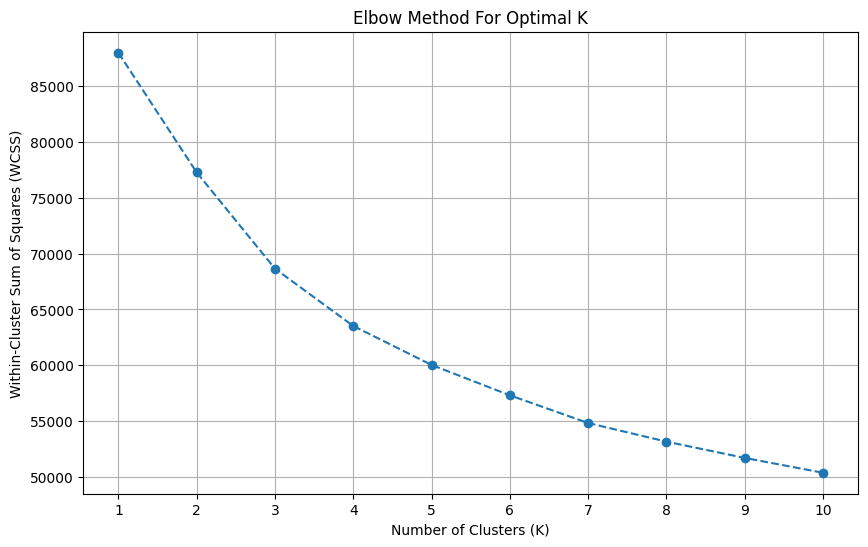

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Test K-Means for a range of cluster numbers, e.g., 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is set to 10 to suppress warning
    kmeans.fit(X_train_scaled) # Use the scaled training data
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Observe the plot above. The 'elbow' point, where the rate of decrease in WCSS (inertia) slows down significantly, suggests the optimal number of clusters. This is the point after which adding more clusters does not significantly improve the fit of the data.

Based on this plot, you can choose an appropriate number of clusters (K).

In [32]:
import joblib

# Save the trained Random Forest model (scaled version) to a .pkl file
model_filename = 'random_forest_model_scaled.pkl'
joblib.dump(rf_model_scaled, model_filename)

print(f'The model has been saved as {model_filename}')

The model has been saved as random_forest_model_scaled.pkl


The `random_forest_model_scaled.pkl` file has been saved to your Colab environment. You can download it by clicking on the folder icon in the left sidebar, navigating to the file, and selecting 'Download'.

### Visualizing the Clusters

Based on the elbow method, let's choose a number of clusters (e.g., 3). We will then apply K-Means and visualize the clusters using Principal Component Analysis (PCA) to reduce the dimensionality for plotting.

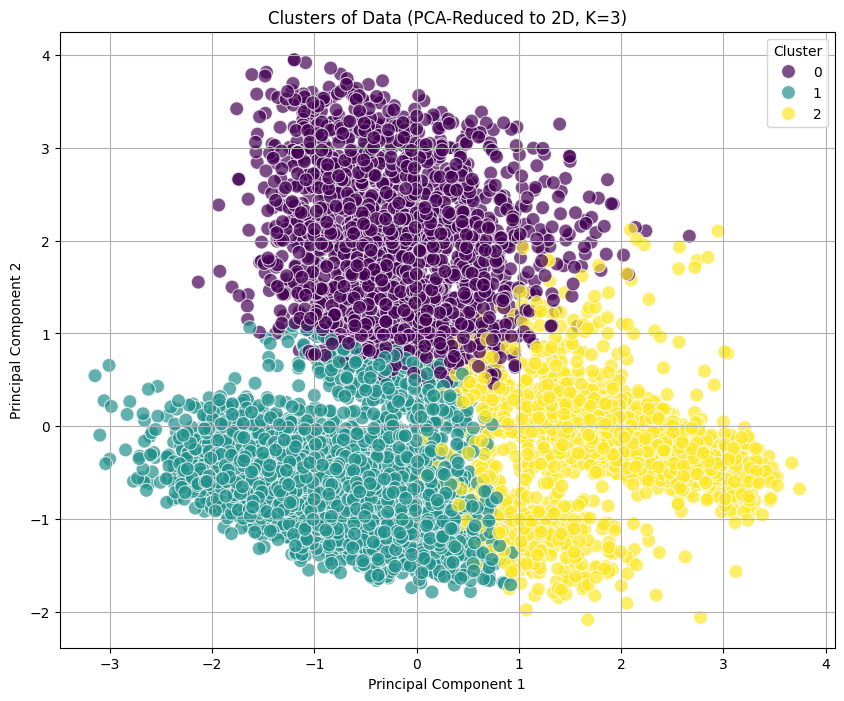

In [30]:
from sklearn.decomposition import PCA
import seaborn as sns # Import seaborn

# Choose the optimal number of clusters based on the Elbow Method plot
# You might want to adjust this value after reviewing the plot
n_clusters = 3 # Example: assuming 3 is chosen from the elbow plot

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])
pca_df['cluster'] = clusters

# Plot the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title(f'Clusters of Data (PCA-Reduced to 2D, K={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [31]:
pca_df.to_csv('clustered_data.csv', index=False)
print('Clustered data saved to clustered_data.csv')

Clustered data saved to clustered_data.csv


The `clustered_data.csv` file has been saved to your Colab environment. You can download it by clicking on the folder icon in the left sidebar, navigating to the file, and selecting 'Download'.

In [26]:
rf_model_scaled = RandomForestClassifier(random_state=42)
rf_model_scaled.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_pred_scaled = rf_model_scaled.predict(X_test_scaled)
print(classification_report(y_test, y_pred_scaled))

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy of the Random Forest model with scaled data: {accuracy_scaled:.4f}")

              precision    recall  f1-score   support

           0       0.57      0.71      0.63       895
           1       0.76      0.64      0.69      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200

Accuracy of the Random Forest model with scaled data: 0.6650


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest model: {accuracy:.4f}")

Accuracy of the Random Forest model: 0.6627
